In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import sys
sys.path.append('/home/wergillius/Project/TIGON')
import utility 
from importlib import reload

from matplotlib import pyplot as plt


In [2]:
import scanpy as sc
import palantir

In [3]:
# ad
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad = sc.read_h5ad(f"{data_path}/combined_filt.h5ad")


# cluster 7 meta
clu7_df = pd.read_csv("/home/wergillius/Project/HSPCdynamics/PD_model/clu_7/tables/table_all_parameters_clu_7.csv", index_col=0)
clu7_df['timepoint_tx_days'] = ad.obs.loc[clu7_df.index, 'timepoint_tx_days'].values
timepoints = np.sort(ad.obs['timepoint_tx_days'].unique()) 


# cellbarcode of z
CB_ay = np.load("../Input/HSPC_clu7_cellbarcode.npy", allow_pickle=True)
CBs = np.concatenate(CB_ay, axis=0)

clu7_ad = ad[CBs].copy()


In [5]:
%%time
dm_res = palantir.utils.run_diffusion_maps(ad, pca_key="X_pca", n_components=30)

CPU times: user 1min 54s, sys: 2min 40s, total: 4min 35s
Wall time: 1min 22s


In [4]:
import mellon

In [5]:
ad

AnnData object with n_obs × n_vars = 130700 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

In [12]:
X = ad.obsm["DM_EigenVectors"]
X_times = ad.obs["timepoint_tx_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
    raise ValueError(
        "You time increments are very different from the tutorial data. "
        "Please choose amn appropriate time span or pass ls_time=None (takes long)."
    )

ValueError: You time increments are very different from the tutorial data. Please choose amn appropriate time span or pass ls_time=None (takes long).

In [14]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of 2
t_est = mellon.TimeSensitiveDensityEstimator(d=2, ls_time=None)

# Fit the estimator to the data
t_est.fit(X, X_times)
density_predictor = t_est.predict

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2024-06-11 04:20:45,862] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (130,700) and rank = 1.0.
[2024-06-11 04:20:45,863] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 04:21:20,797] [INFO    ] Initiating density computation for each time point to estimate the 'ls_time' parameter. You can directly specify 'ls_time' to bypass this computation-intensive step.
[2024-06-11 04:21:20,854] [INFO    ] [1 of 9] Computing density for 7,021 cells at time point 3.0.
[2024-06-11 04:21:20,892] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (7,021) and rank = 1.0.
[2024-06-11 04:21:20,893] [INFO    ] Using covariance function Matern52(ls=0.006933665668915388).
[2024-06-11 04:21:20,894] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 04:21:27,533] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 04:21:29,210] [INFO    ] Running inference using L-BFGS-B.
[2024-

TimeSensitiveDensityEstimator(
    cov_func_curry=<class 'mellon.cov.Matern52'>,
    n_landmarks=5000,
    rank=1.0,
    gp_type=GaussianProcessType.SPARSE_CHOLESKY,
    jitter=1e-06, 
    optimizer=L-BFGS-B,
    landmarks=<array 5,000 landmarks x 31 dims, dtype=float64>,
    nn_distances=<array 130,700 cells, dtype=float64>,
    normalize_per_time_point=False,
    d=2.0,
    mu=0.6906611263575613,
    ls=0.006933665668915388,
    ls_time=1318815734.4832146,
    ls_factor=1.0,
    ls_time_factor=1.0,
    density_estimator_kwargs={},
    cov_func=(Matern52(active_dims=slice(None, -1, None), ls=0.006933665668915388) * Matern52(active_dims=-1, ls=1318815734.4832146)),
    Lp=<array 5,000 landmarks x 5,000 landmarks, dtype=float64>,
    L=<array 130,700 cells x 5,000 ranks, dtype=float64>,
    initial_value=<array 5,000 ranks, dtype=float64>,
    predictor_with_uncertainty=False,
    jit=False,
    check_rank=None,
)

In [ ]:
X_times.unique()

array([269, 161,   7,   3,  27,  12,  76,  49, 112])

In [28]:
plt.rcParams["figure.dpi"] = 80

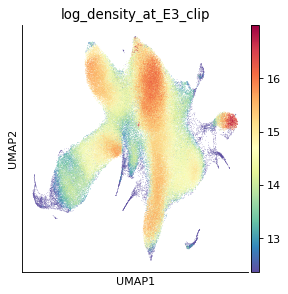

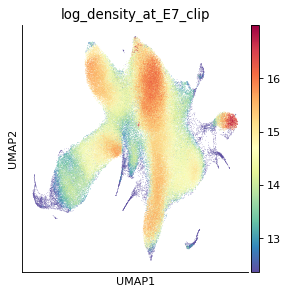

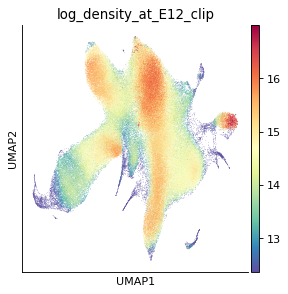

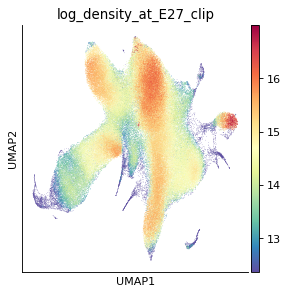

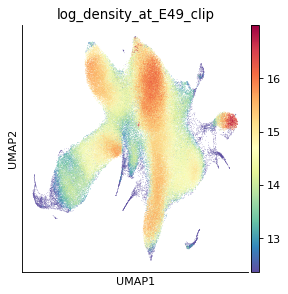

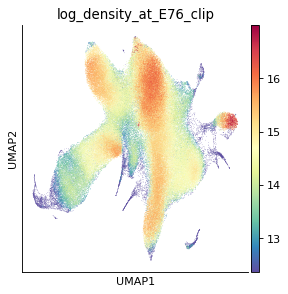

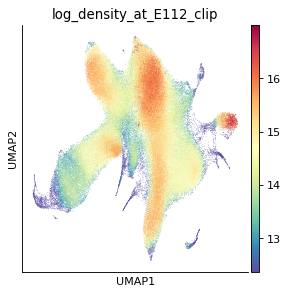

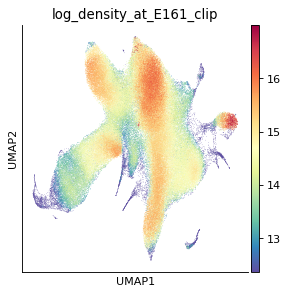

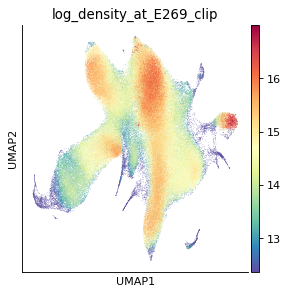

In [29]:
for time in sorted(X_times.unique()):
    log_density = density_predictor(X, time)
    ad.obs[f"log_density_at_E{time}"] = log_density
    ad.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    sc.pl.umap(ad,color=f"log_density_at_E{time}_clip")

In [30]:
ad.uns["density_predictor"] = density_predictor.to_dict()

In [31]:
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad.write_h5ad(f"{data_path}/combined_filt.h5ad")

# Infer with smoothed time point

In [6]:
X_times = ad.obs["timepoint_tx_days"]

In [7]:
ad.obs["smooth_days"] = ad.obs["timepoint_tx_days"].astype(str).map({
    "3":3,
    "7":7,
    "12":12,
    "27":17,
    "49":22,
    "76":27,
    "112":32,
    "161":37,
    "269":42
})

In [8]:
np.sort(X_times.unique())

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [9]:
X = ad.obsm["DM_EigenVectors"]
X_times = ad.obs["smooth_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
# if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
#     raise ValueError(
#         "You time increments are very different from the tutorial data. "
#         "Please choose amn appropriate time span or pass ls_time=None (takes long)."
#     )
print(ls_time_estimate)

7.3125


In [10]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of None
t_est2 = mellon.TimeSensitiveDensityEstimator(d=None, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est2.fit(X, X_times)
density_predictor2 = t_est2.predict

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2024-06-11 16:45:26,821] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (130,700) and rank = 1.0.
[2024-06-11 16:45:26,850] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 16:46:02,448] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=0.006933665668915388) * Matern52(active_dims=-1, ls=7.3125)).
[2024-06-11 16:46:02,660] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 16:49:01,168] [INFO    ] Estimating approximation accuracy since 130,700 samples are more than 10 x 5,000 landmarks.
[2024-06-11 16:50:20,460] [INFO    ] Rank fraction (72.3%, lower is better) is within acceptable range. Current settings should provide satisfactory model performance.
[2024-06-11 16:50:20,462] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 16:50:31,493] [INFO    ] Running inference using L-BFGS-B.
[2024-06-11 17:02:19,629] [INFO    ] Computing predictive functio

NameError: name 't_est' is not defined

In [11]:
density_predictor2 = t_est2.predict

In [12]:
ad2 = ad.copy()

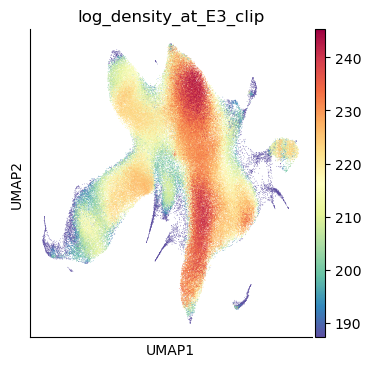

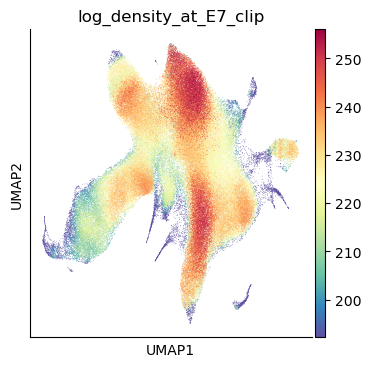

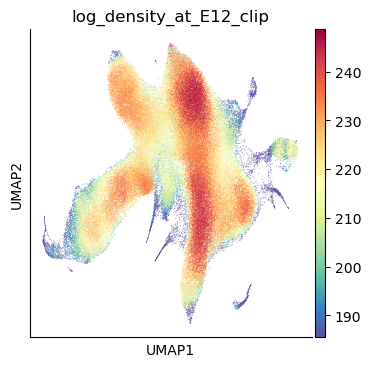

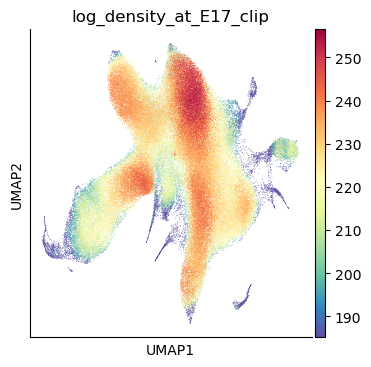

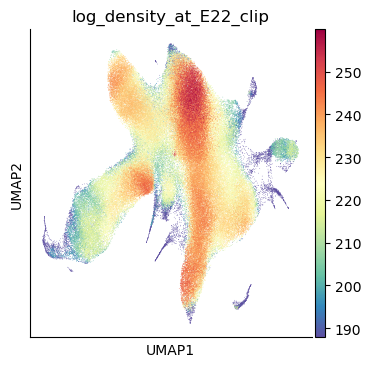

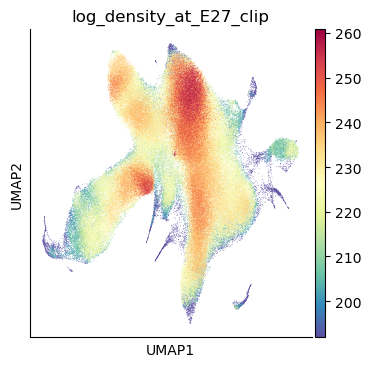

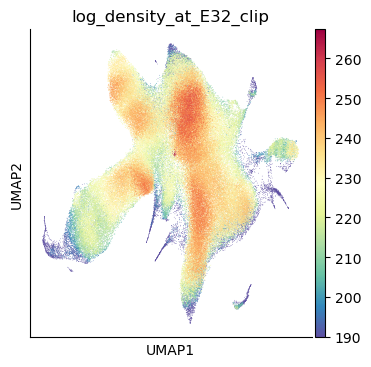

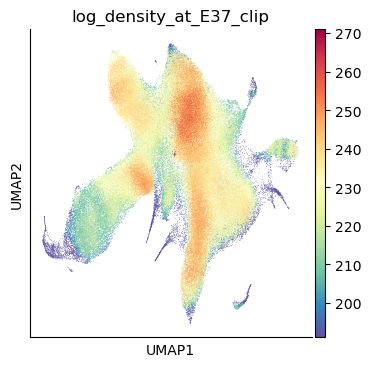

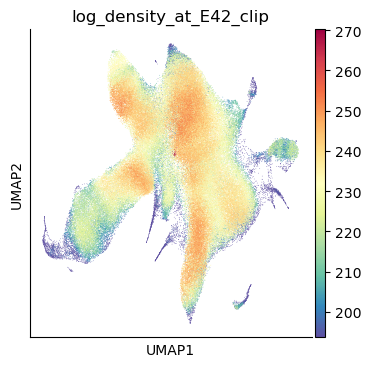

In [14]:
for time in sorted(X_times.unique()):
    log_density = density_predictor2(X, time)
    ad2.obs[f"log_density_at_E{time}"] = log_density
    ad2.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    sc.pl.umap(ad2,color=f"log_density_at_E{time}_clip")

In [15]:
ad2.uns["density_predictor"] = density_predictor2.to_dict()

In [16]:
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad2.write_h5ad(f"{data_path}/combined_filt_dNone.h5ad")

# get out cluster 7

In [ ]:
clu7_ad = ad2[CBs].copy()

7.3125


In [18]:
color_cols = [f"log_density_at_E{time}_clip" for time in sorted(X_times.unique())]

In [21]:
plt.rcParams["figure.dpi"] = 80

In [26]:
import plotting_fn as plfn

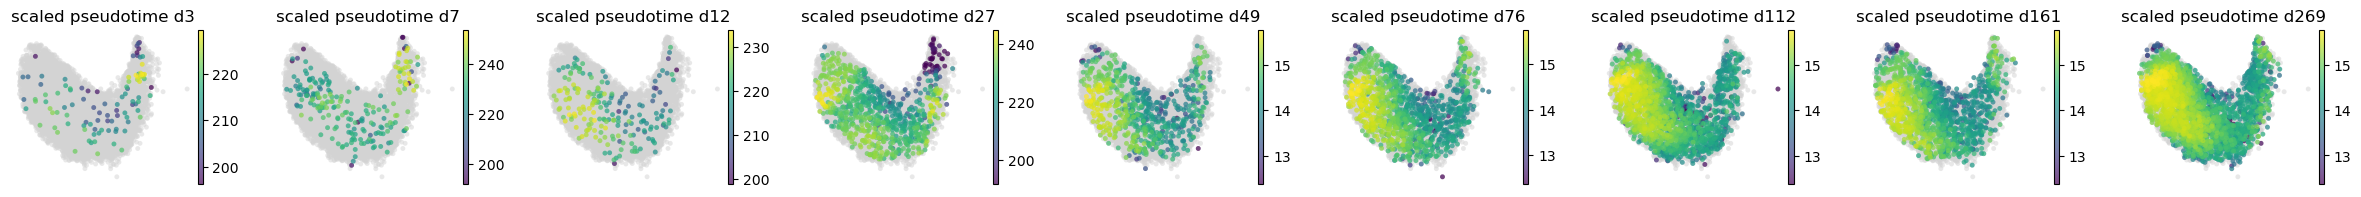

In [24]:
fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
# axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

    sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
    sc.pl.umap(clu7_ad[cbs], color=f"log_density_at_E{t}_clip", alpha=0.7, color_map='viridis', 
            return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
            title='scaled pseudotime d%d'%t);

    axis_j += 1

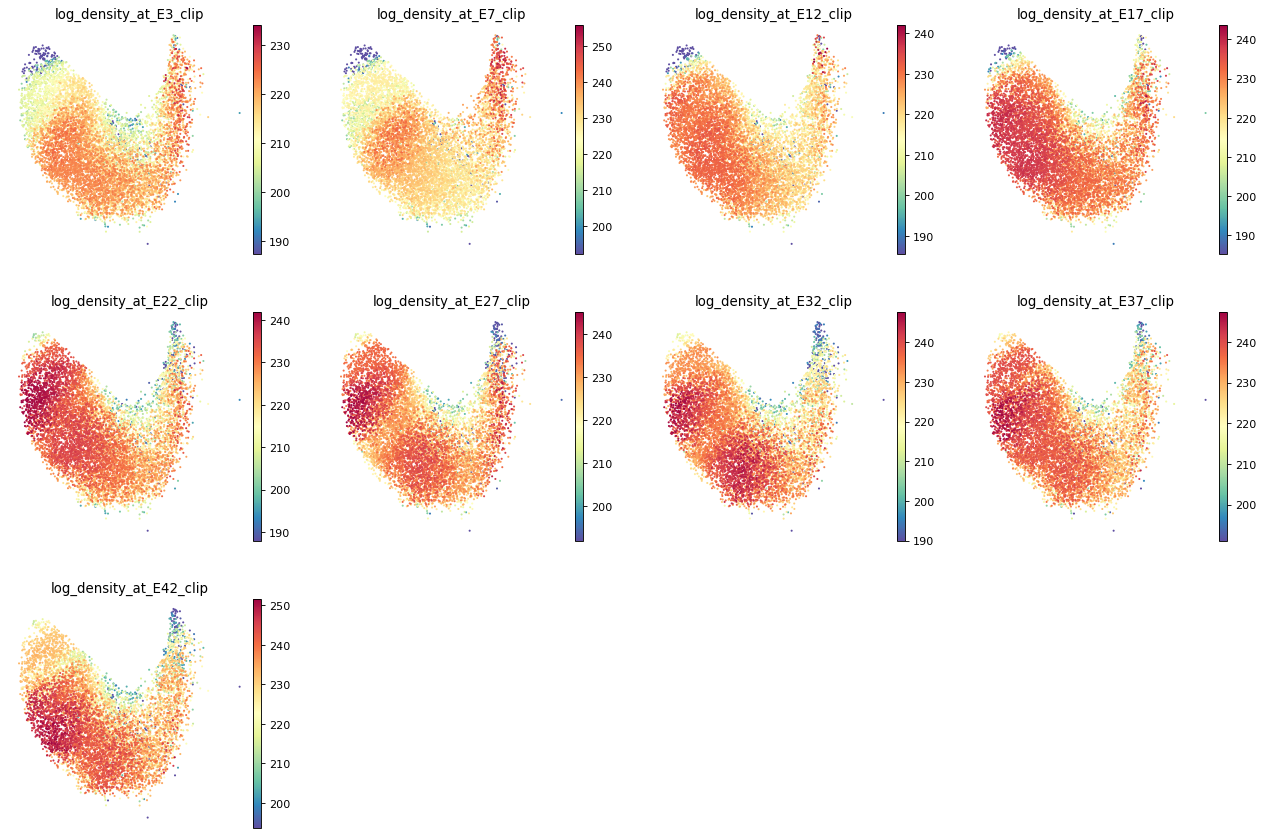

In [22]:
sc.pl.umap(clu7_ad, color=color_cols, frameon=False)

# fit on cluster 7

In [29]:
clu7_ad = ad2[CBs].copy()

X = clu7_ad.obsm["DM_EigenVectors"]
X_times = clu7_ad.obs["smooth_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
# if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
#     raise ValueError(
#         "You time increments are very different from the tutorial data. "
#         "Please choose amn appropriate time span or pass ls_time=None (takes long)."
#     )
print(ls_time_estimate)

7.3125


In [30]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of None
t_est = mellon.TimeSensitiveDensityEstimator(d=None, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est.fit(X, X_times)
density_predictor = t_est.predict

[2024-06-11 22:49:04,144] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (8,704) and rank = 1.0.
[2024-06-11 22:49:04,218] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 22:49:07,432] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=0.0075050301676791685) * Matern52(active_dims=-1, ls=7.3125)).
[2024-06-11 22:49:07,566] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 22:49:15,865] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 22:49:17,757] [INFO    ] Running inference using L-BFGS-B.
[2024-06-11 22:49:42,698] [INFO    ] Computing predictive function.


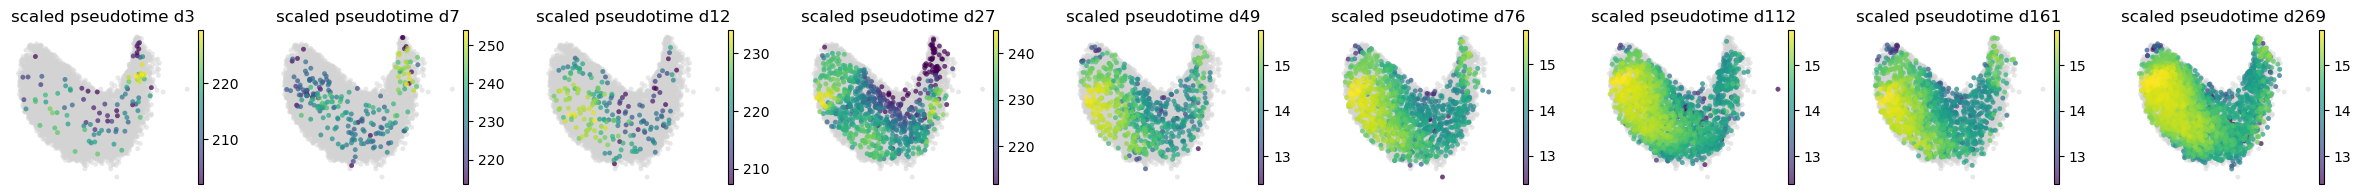

In [31]:
for time in sorted(X_times.unique()):
    log_density = density_predictor2(X, time)
    clu7_ad.obs[f"log_density_at_E{time}"] = log_density
    clu7_ad.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    

fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
# axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

    sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
    sc.pl.umap(clu7_ad[cbs], color=f"log_density_at_E{t}_clip", alpha=0.7, color_map='viridis', 
            return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
            title='log_density_at d%d'%t);

    axis_j += 1

In [34]:
import seaborn as sns

ValueError: Could not interpret value `dpt_pseudotime_scaled` for `x`. An entry with this name does not appear in `data`.

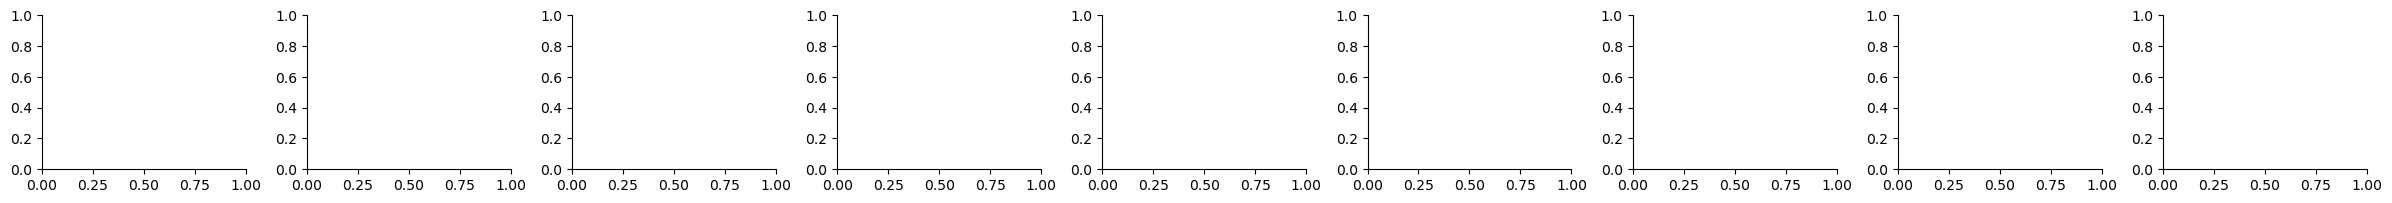

In [35]:
fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
    # axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index
    sns.scatterplot(data=clu7_ad.obs.loc[cbs], x='dpt_pseudotime_scaled', y = f"log_density_at_E{t}_clip", ax=axs[axis_j])
    axis_j += 1

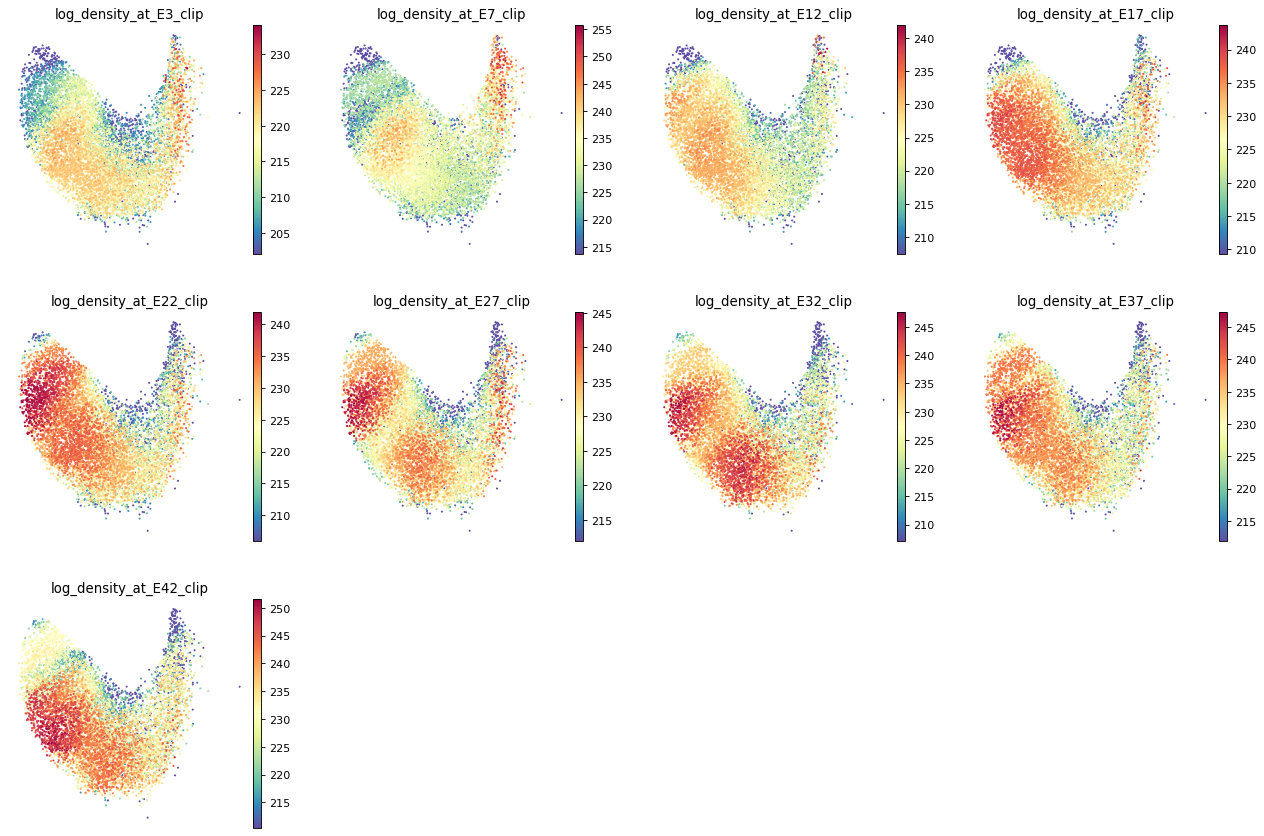

In [32]:
sc.pl.umap(clu7_ad, color=color_cols, frameon=False)

# for cluster 7 and 11